# Tentativo di fit con i diversi dati che abbiamo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import ultranest
import scipy as sp
import ipywidgets as widgets
from dataclasses import dataclass
from typing import Callable
import os

In [2]:
%matplotlib widget
plt.close('all')


## Caricamento dati

In [3]:
# costante dielettrica oro bulk

ns = np.loadtxt("temp/analisi/Au_n.txt")
ks = np.loadtxt("temp/analisi/Au_k.txt")
evs = np.loadtxt("temp/analisi/Au_evs.txt")

optical_consts_lambdas = 1240 / evs

min_lambda = 350
max_lambda = 800

lambda_mask = (optical_consts_lambdas >= min_lambda) & (optical_consts_lambdas <= max_lambda)

eps_m = (ns + 1j*ks)**2    # oro
eps_h = 1 + 0j    # aria
lambdas = optical_consts_lambdas[lambda_mask]

eps_m = eps_m[lambda_mask]

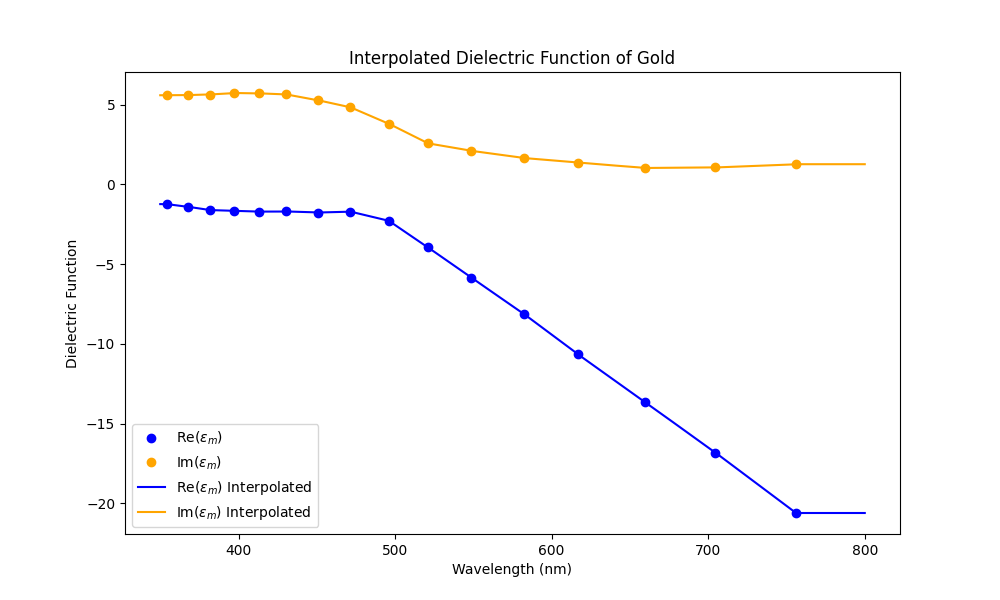

In [4]:
# assicura che sia tutto in ordine crescente di lambda
sorted_indices = np.argsort(lambdas)
lambdas = lambdas[sorted_indices]
eps_m = eps_m[sorted_indices]


# interpolazione su una mesh di lambda più fitta
lambdas_interp = np.linspace(min_lambda, max_lambda, 1000)

eps_m_interp = np.interp(lambdas_interp, lambdas, eps_m)

# plot dei dati interpolati
plt.figure(figsize=(10, 6))
plt.plot(lambdas, eps_m.real, label=r'Re($\epsilon_m$)', color='blue', marker='o', linestyle='None')
plt.plot(lambdas, eps_m.imag, label=r'Im($\epsilon_m$)', color='orange', marker='o', linestyle='None')
plt.plot(lambdas_interp, eps_m_interp.real, label=r'Re($\epsilon_m$) Interpolated', color='blue', linestyle='-')
plt.plot(lambdas_interp, eps_m_interp.imag, label=r'Im($\epsilon_m$) Interpolated', color='orange', linestyle='-')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Dielectric Function')
plt.title('Interpolated Dielectric Function of Gold')
plt.legend()
plt.show()

In [5]:
# riassegna le variabili per sovrascrivere i dati originali con quelli interpolati
lambdas = lambdas_interp
eps_m = eps_m_interp

## Modelli per epsilon efficace
- Modello di Maxwell-Garnett
- Modello di Bruggeman

In [6]:
def eps_mg(eps_m, eps_h, f, L):
    """Maxwell-Garnett generalizzato (esplicito)."""
    return eps_h + (f*eps_h*(eps_m - eps_h)) / (eps_h + (1-f)*L*(eps_m - eps_h))

def eps_bruggeman(eps_m, eps_h, f, L):
    """Bruggeman generalizzato: quadratica + selezione radice passiva."""
    a = 1 - L
    b = -((f - L)*eps_m + (1 - L - f)*eps_h)
    c = -L*eps_m*eps_h
    disc = np.sqrt(b**2 - 4*a*c + 0j)
    r1 = (-b + disc)/(2*a)
    r2 = (-b - disc)/(2*a)
    return np.where(r1.imag >= 0, r1, r2)

In [7]:
def linear_transform(x, A0, A1):
    return A0 + A1*(x)

def absorbance(eps_eff, lam, d, A0, A1):#, c_s, lam0=900.0):
    k_eff = np.sqrt(eps_eff).imag
    A_film = (4*np.pi*d)/(np.log(10)*lam) * k_eff
    return A_film*A1 + A0 #+ linear_transform(lam, A0, A1) + c_s*(lam0/lam)**4

## Infrastruttura: gestione di likelyhood e prior transform

In [8]:
class BaseModel:
    def __init__(self, model: Callable, param_names: list, param_bounds: list, likelihood_func: Callable, prior_transform_func: Callable, data : np.ndarray):

        """
        Classe che rappresenta un modello per i nostri dati.
        
        Arguments:
            model: funzione che calcola il modello teorico
            param_names: lista dei nomi dei parametri del modello
            param_bounds: lista dei limiti dei parametri del modello
            likelihood_func: funzione che calcola la likelihood
            prior_transform_func: funzione che trasforma i parametri da unit cube a prior
            data: dati osservati
        """

        self.model = model
        self.param_names = param_names
        self.param_bounds = param_bounds
        self.likelihood_func = likelihood_func
        self.prior_transform_func = prior_transform_func
        self.data = data

        self.best_fit_params = None
        self.best_fit_likelihood = None
        self.best_fit_evidence = None
        self.sampler = None
    
    def likelihood(self, **params):
        """Calcola la likelihood del modello dato un set di parametri."""
        return self.likelihood_func(**params)
    
    def prior_transform(self, unit_params):
        """Trasforma i parametri da unit cube a prior."""
        return self.prior_transform_func(unit_params)

    def __call__(self, **args):
        """ Calcola la previsione del modello con i parametri best fit e gli argomenti dati. """
        if self.best_fit_params is None:
            raise ValueError("Nessun fit disponibile.")
        return self.model(**self.best_fit_params, **args)

    def fit(self, **kwargs):
        """ Esegue un fit con ultranest e salva i parametri best fit, la likelihood e l'evidenza. """

        sampler = ultranest.ReactiveNestedSampler(self.param_names, self.likelihood, transform=self.prior_transform)
        result = sampler.run(**kwargs)

        self.best_fit_params = {name: result['posterior']['median'][i] for i, name in enumerate(self.param_names)}
        self.best_fit_likelihood = result['loglikelihood']
        self.best_fit_evidence = result['logz']
        self.sampler = sampler
    
    def get_samples(self):
        """ Restituisce i campioni del fit. """
        if self.sampler is None:
            raise ValueError("Nessun fit disponibile.")
        return self.sampler.results['samples'], self.sampler.results['weights']
    
    def get_weighted_samples(self):
        """ Restituisce i campioni pesati del fit. """
        samples, weights = self.get_samples()
        return samples, weights / np.sum(weights)
    
    def build_likelihood(self, likelihood_type):
        """ Costruisce la funzione di likelihood in base al tipo specificato. """
        
        if likelihood_type == "gaussian":
            def likelihood_func(**params):
                model_A = self.model(**params)
                residuals = self.data - model_A
                return -0.5 * np.sum(residuals**2)
            return likelihood_func
        
        else:
            raise ValueError(f"Tipo di likelihood non supportato: {likelihood_type}")
    
    def build_prior_transform(self, prior_types):
        """ Costruisce la funzione di trasformazione dei prior in base ai tipi specificati. """
        
        def prior_transform_func(unit_params):
            transformed_params = []
            for i, (param_name, prior_type) in enumerate(zip(self.param_names, prior_types)):
                if prior_type == "uniform":
                    lower, upper = self.param_bounds[i]
                    transformed_param = lower + unit_params[i] * (upper - lower)
                elif prior_type == "log_uniform":
                    lower, upper = self.param_bounds[i]
                    transformed_param = np.exp(np.log(lower) + unit_params[i] * (np.log(upper) - np.log(lower)))
                elif prior_type == "gaussian":
                    mean, std = self.param_bounds[i]
                    transformed_param = mean + std * sp.stats.norm.ppf(unit_params[i])
                else:
                    raise ValueError(f"Tipo di prior non supportato: {prior_type}")
                transformed_params.append(transformed_param)
            return transformed_params
        return prior_transform_func
    
    def set_data(self, data):
        """ Imposta i dati osservati per il modello. """
        self.data = data
    
    def set_params(self, **params):
        """ Imposta i parametri del modello. """
        self.best_fit_params = params


class AbsorbanceModel(BaseModel):

    absorbance_common_params = ["d", "A0", "A1"] #, "c_s"]
    absorbance_common_bounds = [(0, 100), (-10, 10), (-5, 5)] #, (0, 1)]
    absorbance_common_priors = ["uniform", "uniform", "uniform"]#, "uniform"]

    def __init__(self, eps_func : Callable, data: np.ndarray, param_names: list, param_bounds: list, likelihood_type: str, prior_types: list):

        """ Costruisce un modello di assorbanza basato su una funzione dielettrica effective data da eps_func. """

        self.param_bounds = self.absorbance_common_bounds + param_bounds
        self.param_names = self.absorbance_common_params + param_names
        self.model = lambda **params: absorbance(eps_func(eps_m, eps_h, params['f'], params['L']), lambdas, params['d'], params['A0'], params['A1'])#, params['c_s'])
        likelihood_func = self.build_likelihood(likelihood_type)
        prior_transform_func = self.build_prior_transform(prior_types)

        super().__init__(model=self.model, param_names=self.param_names, param_bounds=self.param_bounds, likelihood_func=likelihood_func, prior_transform_func=prior_transform_func, data=data)
        self.eps_func = eps_func
    


In [ ]:
spettri_dir = "data/spettri/"

available_spectra = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and "reference" not in i]

abs = [] # deve contenere i dati di assorbanza dei vari spettri, quindi deve essere una lista di array numpy

for spectrum in available_spectra:
    data = np.loadtxt(os.path.join(spettri_dir, spectrum))
    abs.append(data[:, 1])

print("Available spectra:")
for i, spectrum in enumerate(available_spectra):
    print(f"{i}: {spectrum}")
    
reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference2.xy"))
ref_abs = reference_spectrum[:, 1]

diff_from_ref = [a - ref_abs for a in abs]

Available spectra:
0: campione_perc_1.xy
1: campione_6nm_1.xy
2: campione_20nm_1.xy
3: campione_9nm_1.xy
4: campione_au_pt_1.xy


In [19]:
# definizione dei modelli specifici (Maxwell-Garnett e Bruggeman)

mg_model = AbsorbanceModel(
    eps_func=eps_mg,
    data=None,  # da impostare successivamente
    param_names=['f', 'L'],
    param_bounds=[(0, 1), (0, 1)],
    likelihood_type="gaussian",
    prior_types=["uniform", "uniform"]
)

bruggeman_model = AbsorbanceModel(
    eps_func=eps_bruggeman,
    data=None,  # da impostare successivamente
    param_names=['f', 'L'],
    param_bounds=[(0, 1), (0, 1)],
    likelihood_type="gaussian",
    prior_types=["uniform", "uniform"]
)




In [21]:
# plot dei modelli con dei parametri di esempio

params = {'f': 0.3, 'L': 0.5, 'd': 50, 'A0': 0, 'A1': 0, 'c_s': 0.1}
param_selectors = {name: widgets.FloatSlider(min=bound[0], max=bound[1], step=0.01, value=params[name], description=name) for name, bound in zip(mg_model.param_names, mg_model.param_bounds)}

mg_model.set_params(**params)
bruggeman_model.set_params(**params)

with plt.ioff():
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(111)

    mg_line, = ax1.plot(lambdas, mg_model(), label="Maxwell-Garnett", color='blue')
    bruggeman_line, = ax1.plot(lambdas, bruggeman_model(), label="Bruggeman", color='orange')

    ax1.set_title("Assorbanza teorica con parametri di esempio")
    ax1.set_xlabel("Lunghezza d'onda (nm)")
    ax1.set_ylabel("Assorbanza")
    ax1.set_xlim(min_lambda, max_lambda)
    ax1.set_ylim(0, 3)
    ax1.legend()

def update_plot(**new_params):

    for key, value in new_params.items():
        params[key] = value

    mg_model.set_params(**params)
    bruggeman_model.set_params(**params)
    mg_line.set_ydata(mg_model())
    bruggeman_line.set_ydata(bruggeman_model())

    # aggiorna limiti in y
    all_y = np.concatenate([mg_model(), bruggeman_model()])
    ax1.set_ylim(np.min(all_y), np.max(all_y))


    fig.canvas.draw_idle()

for selector, name in zip(param_selectors.values(), mg_model.param_names):
    selector.observe(lambda change, name=name: update_plot(**{name: change['new']}), names='value')

update_plot(**params)

label_text = """I parametri modificabili sono:
- d: spessore del film (nm)
- A0: offset lineare dell'assorbanza
- A1: coefficiente lineare dell'assorbanza
- c_s: coefficiente di scattering (con dipendenza lambda^-4)
- f: frazione volumetrica di oro
- L: fattore di forma (0 = sfere, 1 = dischi)
"""

selectors_box = widgets.VBox(list(param_selectors.values()))
label_box = widgets.VBox([widgets.Label(line) for line in label_text.split('\n')])
ui = widgets.HBox([selectors_box, label_box])
display(widgets.VBox([ui, fig.canvas]))

/tmp/ipykernel_7409/1388858926.py:35: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax1.set_ylim(np.min(all_y), np.max(all_y))
